# System with ON/OFF states

In [1]:
#user = r"\SagixOffice"  # HomeOffice
user = r"\vie43sq"  # University
import sys
sys.path.append(rf"C:\Users{user}\OneDrive - Universität Würzburg\GitHub\Photoswitching")

import numpy as np
import src.fluorophore_systems as fs
import src.custom_plot as cp
from IPython.display import HTML

%load_ext autoreload
%autoreload 2

### Define the state transition rates

In [8]:
rate_dict = dict(k_ON_OFF=10,  # reduction  
                 k_OFF_ON=0.06,  # oxidation
                 k_ON_B=0.3)  # bleaching

### Initialize system

In [9]:
system = fs.OnOffModel(number=3, distances=1, rates=rate_dict, induction_rate=None)

### Simulate the Markov process

In [10]:
time_series, time_step_series, state_series = system.simulate(n_steps=1000, seed=100, base="cy")

### Receive emission data

In [18]:
emissions, emission_time_series = system.emitters(s0s1_rate=1e4, s1s0_rate=1e7, resample=5e-3, seed=100)

371.8820384361795


### Unique states and their occupation times
Example: ON_OFF and OFF_ON are united

In [10]:
unique_series_converted, unqiue_states, occupation_times = system.process()

## Visualize

In [11]:
system.animate(index_range=100, saveas="animations\on_off.mp4")

In [12]:
HTML("""
<div align="middle">
<video width="80%" controls>
      <source src="on_off.mp4" type="video/mp4">
</video></div>""")

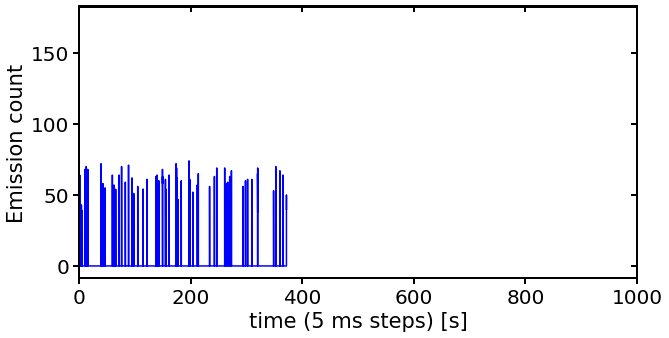

In [98]:
fig, ax = cp.universal_figure(type_="line", data=[system.emission_time_series, system.emissions], 
                              ylabel="Emission count", 
                              xlabel="time (5 ms steps) [s]", xlim=[0, 1000])